In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

This report analyzes the performance of six different volatility forecasting methods. Part 1 verifies the implementation of these estimators against the results published in Artur Sepp's 2016 paper, *Volatility Modeling and Trading*. Part 2 extends this analysis to a broader set of ETFs over a modern backtest period.

# Part 1: Sepp (2016) Replication

This section replicates the regression coefficient and R² metric for six weekly volatility estimators on the SPY ETF. The analysis is performed over the backtest period from **January 1, 2005, to April 2, 2016**, to match the timeframe used in Sepp's paper.

Our data is taken from `yfinance`, and with a few extra data wrangling steps, we take the raw data and transform it to obtain a week start and end date for each daily observation.

In [2]:
daily_spy_df = pd.read_csv('../data/individual_ticker_data/SPY.csv', parse_dates=True)
daily_spy_df = daily_spy_df[daily_spy_df['trade_date'] <= '2016-04-02']
daily_spy_df

,ticker,trade_date,week_num,week_start,week_end,adj_close,close,high,low,open,volume,dly_ret
0,SPY,2005-01-03,0,2005-01-03,2005-01-07,81.847122,120.300003,121.760002,119.900002,121.559998,55748000,-0.004716
1,SPY,2005-01-04,0,2005-01-03,2005-01-07,80.846992,118.830002,120.540001,118.440002,120.459999,69167600,-0.012219
2,SPY,2005-01-05,0,2005-01-03,2005-01-07,80.289078,118.010002,119.250000,118.000000,118.739998,65667300,-0.006901
3,SPY,2005-01-06,0,2005-01-03,2005-01-07,80.697334,118.610001,119.150002,118.260002,118.440002,47814700,0.005084
4,SPY,2005-01-07,0,2005-01-03,2005-01-07,80.581657,118.440002,119.230003,118.129997,118.970001,55847700,-0.001433
...,...,...,...,...,...,...,...,...,...,...,...,...
2826,SPY,2016-03-28,586,2016-03-28,2016-04-01,173.653748,203.240005,203.860001,202.710007,203.610001,62408200,0.000591
2827,SPY,2016-03-29,586,2016-03-28,2016-04-01,175.260071,205.119995,205.250000,202.399994,202.759995,92922900,0.009250
2828,SPY,2016-03-30,586,2016-03-28,2016-04-01,176.028992,206.020004,206.869995,205.589996,206.300003,86365300,0.004388
2829,SPY,2016-03-31,586,2016-03-28,2016-04-01,175.601868,205.520004,206.410004,205.330002,205.910004,94584100,-0.002427


We now calculate realized volatility for SPY over the desired period for each week. By Sepp's convention, we use arithmetic returns: $$r_t^{(a)}=\frac{S_t}{S_{t-1}}-1.$$ The realized variance we utilize is simply the Close-to-Close estimator: $$\sigma_t^2(T) = \frac{1}{T-1} \sum_{k=1}^{T} (r_{t-k} - \bar{r}_t(T))^2.$$

In [3]:
spy_realized = \
    (
    daily_spy_df
        .groupby(['week_num', 'week_start', 'week_end'], as_index = False)[['dly_ret']].agg(lambda x: np.std(x, ddof=1) * np.sqrt(252))
        .rename(columns = {'dly_ret':'realized_vol'})
    )
spy_realized

,week_num,week_start,week_end,realized_vol
0,0,2005-01-03,2005-01-07,0.102138
1,1,2005-01-10,2005-01-14,0.104154
2,2,2005-01-18,2005-01-21,0.146252
3,3,2005-01-24,2005-01-28,0.033285
4,4,2005-01-31,2005-02-04,0.078090
...,...,...,...,...
582,582,2016-02-29,2016-03-04,0.179394
583,583,2016-03-07,2016-03-11,0.154242
584,584,2016-03-14,2016-03-18,0.064843
585,585,2016-03-21,2016-03-24,0.055419


## Estimator Calculation

We now calculate the the other four estimators (excluding GARCH).

Parkinson: $$\sigma_t^2(T) = \frac{1}{4 \ln(2)} \sum_{k=1}^{T} \left( \ln \frac{H_k}{L_k} \right)^2$$ where $H_k$ and $L_k$ are the intraday high and low prices.

Garman-Klass: $$\sigma_t^2(T) = \sum_{k=1}^{T} \left[ \frac{1}{2} \left( \ln \frac{H_k}{L_k} \right)^2 - (2 \ln(2) - 1) \left( \ln \frac{C_k}{O_k} \right)^2 \right]$$ which is an extension of the Parkinson estimator, using open and close prices denoted as $O_k$ and $C_k$ respectively.

Rogers-Satchell: $$\sigma_t^2(T) = \sum_{k=1}^{T} \left[ \ln \left( \frac{H_k}{C_k} \right) \ln \left( \frac{H_k}{O_k} \right) + \ln \left( \frac{L_k}{C_k} \right) \ln \left( \frac{L_k}{O_k} \right) \right]$$ which makes no assumption about a zero mean.

Yang-Zhang: $$\sigma_t^2(T) = \sigma_{\text{overnight}}^2(T) + c\sigma_{\text{open-to-close}}^2(T) + (1-c)\sigma_{\text{Rogers-Satchell}}^2(T)$$ where $$\sigma_{\text{overnight}}^2(T) = \sum_{k=1}^{T} \left( \ln \frac{O_k}{C_{k-1}} - \overline{\ln \frac{O_k}{C_{k-1}}} \right)^2,$$ $$\sigma_{\text{open-to-close}}^2(T) = \sum_{k=1}^{T} \left( \ln \frac{C_k}{O_k} - \overline{\ln \frac{C_k}{O_k}} \right)^2,$$ and $$c = \frac{0.34}{1.34 + \frac{T+1}{T-1}}.$$ This estimator works with drift and overnight jumps.

In [4]:
basic_forecasts_full = pd.read_csv('../data/basic_forecasts/SPY_basic_forecast.csv', parse_dates=True)
basic_forecasts_p1 = basic_forecasts_full[basic_forecasts_full['trade_date'] <= '2016-04-02'].copy()
basic_forecasts_p1.head()

,trade_date,close_to_close,parkinson,garman_klass,rogers_satchell,yang_zhang
0,2005-01-07,0.102138,0.269486,0.257288,0.246317,0.245690
1,2005-01-14,0.104154,0.191756,0.196284,0.200665,0.210659
2,2005-01-21,0.146252,0.215565,0.179217,0.151105,0.180176
3,2005-01-28,0.033285,0.147761,0.166406,0.184227,0.183102
4,2005-02-04,0.078090,0.163493,0.151878,0.142885,0.146854


We also use a GARCH(1, 1), which is able to capture some key qualities of volatility such as clustering and mean-reversion, to forecast realized volatility. It is trained on 7-10 years of data, depending on the data availability for the first forecast.

In [5]:
garch_forecast_p1 = pd.read_csv('../data/garch_forecasts/SPY_variance_forecast.csv', parse_dates=True)
garch_forecast_p1 = garch_forecast_p1[garch_forecast_p1['trade_date'] <= '2016-04-02'].copy()
# Taking daily forecasts and aggregating to weekly
garch_forecast_p1['volatility_forecast'] = np.sqrt((garch_forecast_p1['h.1'] + garch_forecast_p1['h.2'] + garch_forecast_p1['h.3'] + garch_forecast_p1['h.4'] + garch_forecast_p1['h.5']) / 100)
garch_forecast_p1 = spy_realized.merge(
        garch_forecast_p1[['trade_date', 'volatility_forecast']],
        left_on = 'week_end',
        right_on = 'trade_date',
    ).drop(columns = ['realized_vol'])
garch_forecast_p1.head()

,week_num,week_start,week_end,trade_date,volatility_forecast
0,0,2005-01-03,2005-01-07,2005-01-07,0.151515
1,1,2005-01-10,2005-01-14,2005-01-14,0.153507
2,2,2005-01-18,2005-01-21,2005-01-21,0.171928
3,3,2005-01-24,2005-01-28,2005-01-28,0.149295
4,4,2005-01-31,2005-02-04,2005-02-04,0.153360


To correctly test the estimators, we must align the data. A forecast made at the end of week `t` is a prediction for the volatility of week `t+1`. Therefore, we shift all forecast series forward by one week before merging them with the realized volatility.

In [6]:
all_forecasts_p1 = basic_forecasts_p1.copy()
all_forecasts_p1 = all_forecasts_p1.merge(
    garch_forecast_p1[['week_end', 'volatility_forecast']],
    left_on = 'trade_date',
    right_on = 'week_end',
).drop(columns = ['week_end'])
all_forecasts_p1.rename(columns = {'volatility_forecast':'garch'}, inplace = True)
# Lagging vol forecasts to align with next week realized
all_forecasts_p1_shifted = all_forecasts_p1.set_index('trade_date').shift(1).reset_index()
all_forecasts_p1_shifted.head()

,trade_date,close_to_close,parkinson,garman_klass,rogers_satchell,yang_zhang,garch
0,2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-14,0.102138,0.269486,0.257288,0.246317,0.245690,0.151515
2,2005-01-21,0.104154,0.191756,0.196284,0.200665,0.210659,0.153507
3,2005-01-28,0.146252,0.215565,0.179217,0.151105,0.180176,0.171928
4,2005-02-04,0.033285,0.147761,0.166406,0.184227,0.183102,0.149295


In [7]:
# Combining forecasts with target variable
results_p1 = all_forecasts_p1_shifted.copy()
results_p1 = results_p1.merge(
    spy_realized[['week_end', 'realized_vol']],
    left_on = 'trade_date',
    right_on = 'week_end',
).drop(columns = ['week_end'])
results_p1.dropna(inplace=True)
results_p1.reset_index(drop=True, inplace=True)
results_p1.head()

,trade_date,close_to_close,parkinson,garman_klass,rogers_satchell,yang_zhang,garch,realized_vol
0,2005-01-14,0.102138,0.269486,0.257288,0.246317,0.245690,0.151515,0.104154
1,2005-01-21,0.104154,0.191756,0.196284,0.200665,0.210659,0.153507,0.146252
2,2005-01-28,0.146252,0.215565,0.179217,0.151105,0.180176,0.171928,0.033285
3,2005-02-04,0.033285,0.147761,0.166406,0.184227,0.183102,0.149295,0.078090
4,2005-02-11,0.078090,0.163493,0.151878,0.142885,0.146854,0.153360,0.094590


## Performance Metrics Calculation

We now calculate the two required metrics for each estimator:\
1.  **R² (R-squared):** Measures the proportion of variance in the realized volatility that is predictable from the estimator. 
2.  **Regression Coefficient (Beta):** In a regression of $$\hat{\sigma}^{Close-to-Close}_{t+1}(T) = \alpha + \beta \hat{\sigma}^{Estimator}_{t}(T) + \epsilon_{t+1},$$a $\beta$ close to 1.0 indicates an efficient and unbiased forecast.

In [8]:
estimators = ['close_to_close', 'parkinson', 'garman_klass', 'rogers_satchell', 'yang_zhang', 'garch']
metrics_p1 = pd.DataFrame(index=estimators, columns=['R-Squared', 'Coefficient', 'R-Squared (Sepp)', 'Coefficient (Sepp)'])

# Loop through each estimator to calculate its performance
for estimator in metrics_p1.index:
    X = results_p1[[estimator]]
    y = results_p1['realized_vol']
    
    # Fit the linear regression model
    model = LinearRegression().fit(X, y)
    coef = model.coef_[0]
    
    metrics_p1.loc[estimator, 'R-Squared'] = round(model.score(X, y), 2)
    metrics_p1.loc[estimator, 'Coefficient'] = round(coef, 2)

# Paper-reported metrics
metrics_p1['R-Squared (Sepp)'] = [0.46, 0.60, 0.62, 0.62, 0.64, 0.46]
metrics_p1['Coefficient (Sepp)'] = [0.48, 0.72, 0.72, 0.69, 0.61, 'not reported']

metrics_p1_col_order = ['R-Squared', 'R-Squared (Sepp)', 'Coefficient', 'Coefficient (Sepp)']
metrics_p1 = metrics_p1[metrics_p1_col_order]
metrics_p1

,R-Squared,R-Squared (Sepp),Coefficient,Coefficient (Sepp)
close_to_close,0.41,0.46,0.64,0.48
parkinson,0.61,0.60,0.47,0.72
garman_klass,0.61,0.62,0.46,0.72
rogers_satchell,0.59,0.62,0.44,0.69
yang_zhang,0.59,0.64,0.4,0.61
garch,0.56,0.46,0.69,not reported


The results from our implementation align well with the findings in Sepp (2016). The $R^2$ values are closely matched, confirming that our implementation of the estimators is correct and that the Parkinson and Garman-Klass estimators are the most effective estimators in terms of correlation.



It is important to note that while the $R^2$ values are similar, our calculated regression coefficients are consistently lower than those reported in the paper. This discrepancy is likely due to differences in the historical OHLC data between our modern ``yfinance`` data source and the one used in the original 2016 analysis. Minor variations in daily high and low prices, which are common due to data vendor revisions, can lead to forecasts with a higher variance, which would effectively decrease $\beta$.

# Part 2: Extended Backtest

## Backtest Description

Having verified our estimator implementations against the 2005-2016 period in Part 1, we now conduct an "out-of-sample" backtest (in a sense). This analysis evaluates the performance of the six estimators on a completely separate and more recent dataset, running from **April 3, 2016 to September 30, 2025**.

This modern period provides a robust testing ground, as it contains several distinct market regimes that differ from the Part 1 data, such as the low-volatility environment of 2017 or the COVID-19 market crash and recovery. By testing on this unseen data, we can more reliably assess which estimator is the most robust and practical for real-world forecasting. The analysis is extended to a set of 10 major sector ETFs to ensure the findings are not specific to the broader market alone.

The ETFs analyzed in this study are:

- SPY: S&P 500 Index
- XLB: Materials Select SPDR
- XLE: Energy Select SPDR
- XLF: Financial Select SPDR
- XLI: Industrial Select SPDR
- XLK: Technology Select SPDR
- XLP: Consumer Staples Select SPDR
- XLU: Utilities Select SPDR
- XLV: Health Care Select SPDR
- XLY: Consumer Discretionary Select SPDR

## Evaluation Metrics

To provide a holistic view of model performance, two complementary metrics are used for evaluation.

1.  **Sepp's $R^2$:** As in Part 1, $R^2$ is used to measure the **directional accuracy** of the forecasts. It quantifies the proportion of variance in realized volatility that is explained by the model, telling us how well the forecasts correlate with the actual outcomes. A higher $R^2$ indicates a model that is better at correctly identifying shifts between high and low volatility.

2. **Root Mean Squared Error (RMSE)**: As my second metric, I have chosen RMSE to measure the **magnitude of forecast error**. While $R^2$ measures correlation, it is insensitive to scale or bias. RMSE addresses this weakness by quantifying the actual *error* of the forecast. For any financial application knowing the absolute error of a forecast is critical, rather than just the correlation. Furthermore, by squaring the errors, RMSE heavily penalizes the larger forecast errors, leading to a better understanding of each estimator's accuracy. Finally, it is also very interpretable, as it measures the typical error of the forecast in the original units of the data (annualized volatility points).


In [9]:
tickers = ['SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
start_date_p2 = '2016-04-02'

# Multi index to store metrics
cols = pd.MultiIndex.from_product([['R²', 'RMSE'], 
                                   ['close_to_close', 'parkinson', 'garman_klass', 'rogers_satchell', 'yang_zhang', 'garch']],
                                  names=['Metric', 'Estimator'])
metrics_p2 = pd.DataFrame(index=tickers, columns=cols, dtype=float)

# Final result dict
aligned_results_data = {}

Next, we loop through each ticker. In each iteration, we load all the necessary pre-computed data: the realized volatility, the five basic estimator forecasts, and the GARCH forecasts. All data is then sliced to the Part 2 backtest period.

Again, the forecast data is shifted forward by one week. This aligns the forecast made at the end of week `t` with the realized volatility of week `t+1`, to predict next week's volatility. The final aligned data for each ticker is stored for the next step.

In [10]:
for ticker in tickers:
    daily_df = pd.read_csv(f'../data/individual_ticker_data/{ticker}.csv', parse_dates=True)
    daily_df = daily_df[daily_df['trade_date'] >= start_date_p2].copy()
    realized_vol = \
        (
        daily_df
            .groupby(['week_num', 'week_start', 'week_end'], as_index = False)[['dly_ret']].agg(lambda x: np.std(x, ddof=1) * np.sqrt(252))
            .rename(columns = {'dly_ret':'realized_vol'})
        )
    
    # Basic Forecasts
    basic_forecasts = pd.read_csv(f'../data/basic_forecasts/{ticker}_basic_forecast.csv', parse_dates=True)
    basic_forecasts = basic_forecasts[basic_forecasts['trade_date'] >= start_date_p2].copy()

    # GARCH Forecasts
    garch_forecasts = pd.read_csv(f'../data/garch_forecasts/{ticker}_variance_forecast.csv', parse_dates=True)
    garch_forecasts = garch_forecasts[garch_forecasts['trade_date'] >= start_date_p2].copy()
    garch_forecasts['volatility_forecast'] = np.sqrt((garch_forecasts['h.1'] + garch_forecasts['h.2'] + garch_forecasts['h.3'] + garch_forecasts['h.4'] + garch_forecasts['h.5']) / 100)
    garch_forecasts = realized_vol.merge(
        garch_forecasts[['trade_date', 'volatility_forecast']],
        left_on = 'week_end',
        right_on = 'trade_date',
    ).drop(columns = ['realized_vol'])
    
    # Combine forecasts
    all_forecasts = basic_forecasts.copy()
    all_forecasts = all_forecasts.merge(
        garch_forecasts[['week_end', 'volatility_forecast']],
        left_on = 'trade_date',
        right_on = 'week_end',
    ).drop(columns = ['week_end'])
    all_forecasts.rename(columns = {'volatility_forecast':'garch'}, inplace = True)
    all_forecasts_shifted = all_forecasts.set_index('trade_date').shift(1).reset_index()

    # Merge forecasts with target
    results = all_forecasts_shifted.copy()
    results = results.merge(
        realized_vol[['week_end', 'realized_vol']],
        left_on='trade_date',
        right_on='week_end'
    ).drop(columns=['week_end'])
    results = results.dropna().reset_index(drop=True)

    aligned_results_data[ticker] = results

For example, the forecasts and realized volatility for XLF are shown below.

In [11]:
aligned_results_data['XLF'].head()

,trade_date,close_to_close,parkinson,garman_klass,rogers_satchell,yang_zhang,garch,realized_vol
0,2016-04-15,0.168957,0.258597,0.263332,0.262355,0.324407,0.236681,0.162560
1,2016-04-22,0.162560,0.261344,0.243643,0.242795,0.296845,0.248927,0.133258
2,2016-04-29,0.133258,0.259002,0.221802,0.193451,0.207797,0.235363,0.103379
3,2016-05-06,0.103379,0.227364,0.259223,0.272583,0.283304,0.212253,0.140081
4,2016-05-13,0.140081,0.229657,0.225783,0.234072,0.291000,0.206760,0.168230


With the data for each ticker now properly loaded and aligned, we can calculate the performance metrics for each estimator.

## Performance

We now compute the R² and RMSE for each estimator's volatility forecast for each ETF.

In [12]:
for ticker, results_df in aligned_results_data.items():
    for estimator in results_df.columns.drop(['realized_vol', 'trade_date']):
        forecast = results_df[estimator]
        actual = results_df['realized_vol']
        
        # R²
        r2 = np.corrcoef(forecast, actual)[0, 1] ** 2
        
        # RMSE
        rmse = np.sqrt(np.mean((forecast - actual) ** 2))
        
        metrics_p2.loc[ticker, ('R²', estimator)] = r2
        metrics_p2.loc[ticker, ('RMSE', estimator)] = rmse
metrics_p2

Metric                R²                                                    \
Estimator close_to_close parkinson garman_klass rogers_satchell yang_zhang   
SPY             0.440818  0.456330     0.468336        0.461329   0.474640   
XLB             0.333705  0.392904     0.416664        0.416497   0.431650   
XLE             0.372399  0.453829     0.470956        0.471806   0.478505   
XLF             0.360516  0.405610     0.417150        0.412944   0.426389   
XLI             0.355030  0.396973     0.412168        0.396507   0.416404   
XLK             0.388434  0.417989     0.442065        0.445208   0.448402   
XLP             0.363712  0.424061     0.428724        0.422988   0.452496   
XLU             0.413297  0.457806     0.462512        0.471431   0.512147   
XLV             0.381296  0.415664     0.434817        0.418641   0.446816   
XLY             0.393515  0.466637     0.477985        0.469881   0.476776   

Metric                        RMSE                                         \
Estimator     garch close_to_close parkinson garman_klass rogers_satchell   
SPY        0.480979       0.097900  0.169380     0.170010        0.174321   
XLB        0.389568       0.111788  0.191913     0.190156        0.193361   
XLE        0.456079       0.161312  0.268433     0.270779        0.276138   
XLF        0.401010       0.128402  0.201829     0.203842        0.207076   
XLI        0.411029       0.111713  0.191438     0.194232        0.202106   
XLK        0.423431       0.130847  0.211250     0.203678        0.203711   
XLP        0.434959       0.082183  0.154603     0.154467        0.157361   
XLU        0.439045       0.099798  0.204953     0.203879        0.205595   
XLV        0.453470       0.086855  0.169628     0.168601        0.172424   
XLY        0.465567       0.113650  0.203180     0.202149        0.205442   

Metric                          
Estimator yang_zhang     garch  
SPY         0.217541  0.126111  
XLB         0.240811  0.139474  
XLE         0.337600  0.204225  
XLF         0.265458  0.153370  
XLI         0.246669  0.134490  
XLK         0.262848  0.159958  
XLP         0.180278  0.098599  
XLU         0.226559  0.126034  
XLV         0.203071  0.111514  
XLY         0.263329  0.142758

To get a clearer picture of which estimator is more accurate on average, we compute the mean $R^2$ and mean RMSE for each method across all 10 ETFs.

In [13]:
average_metrics = metrics_p2.mean(axis=0)

# Putting in more readable format
summary_table = average_metrics.unstack(level='Estimator').T
summary_table.rename(columns={'R²': 'Average R²', 'RMSE': 'Average RMSE'}, inplace=True)
summary_table

Metric,Average RMSE,Average R²
Estimator,,
close_to_close,0.112445,0.380272
garch,0.139653,0.435514
garman_klass,0.196179,0.443138
parkinson,0.196661,0.428780
rogers_satchell,0.199753,0.438723
yang_zhang,0.244416,0.456423


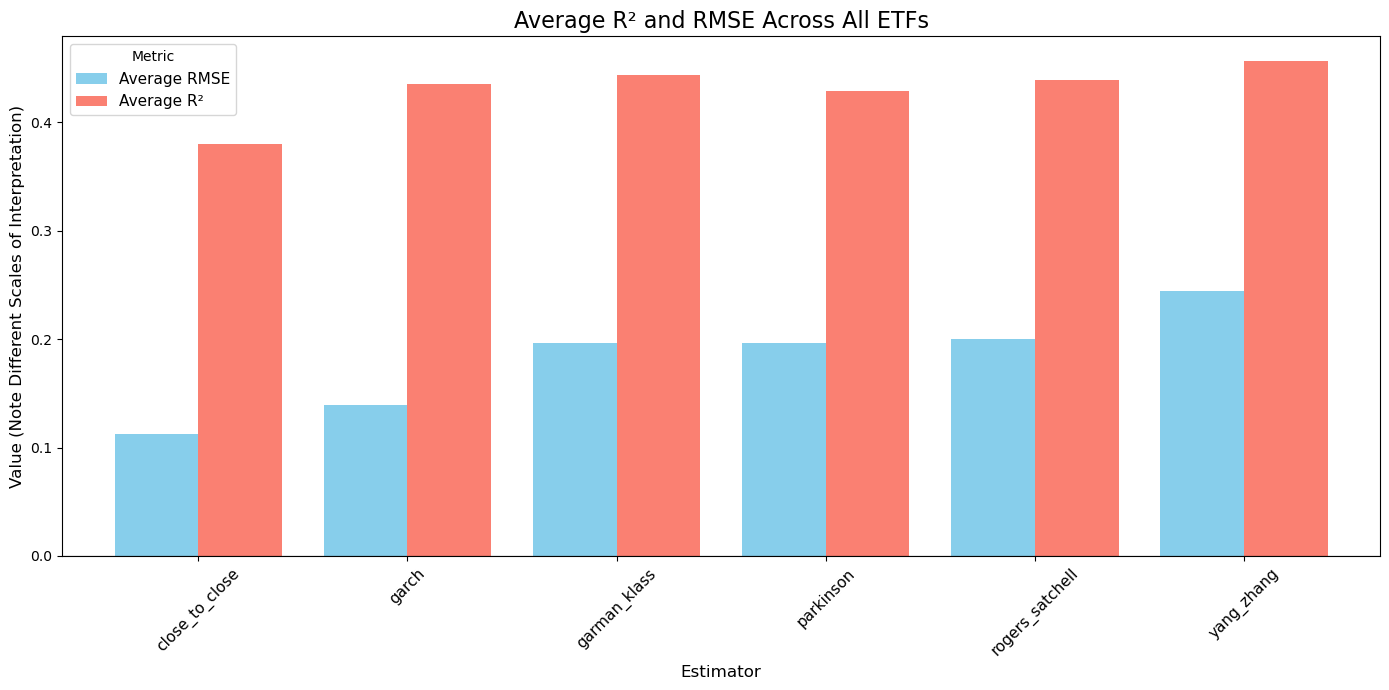

In [14]:
ax = summary_table.plot(
    kind='bar', 
    figsize=(14, 7), 
    color=['skyblue', 'salmon'],
    width=0.8 
)

ax.set_title('Average R² and RMSE Across All ETFs', fontsize=16)
ax.set_ylabel('Value (Note Different Scales of Interpretation)', fontsize=12)
ax.set_xlabel('Estimator', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.legend(title='Metric', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

The summary table averages the performance of each estimator across all 10 ETFs on $R^2$ and RMSE. The Yang-Zhang estimator is the best at identifying the directionality of volatility, with the highest $R^2$ of 0.4572. Its forecasts are most closely correlated with the actual outcomes, making it very effective for predicting the overall volatility of the market environment in the future.

However, the Close-Close estimator's forecasts have the lowest RMSE at 0.1085, meaning on average, it is 10 basis points off on a volatility forecast. While this may seem very high, forecasting the actual value of realized volatility is a very difficult task.

Additionally, the GARCH(1, 1) provides the best balance with one of the highest $R^2$ values (0.4409) and the second-lowest RMSE (0.1489).

To further explore these results, we examine a specific time-series to understand why certain estimators perform better than others.

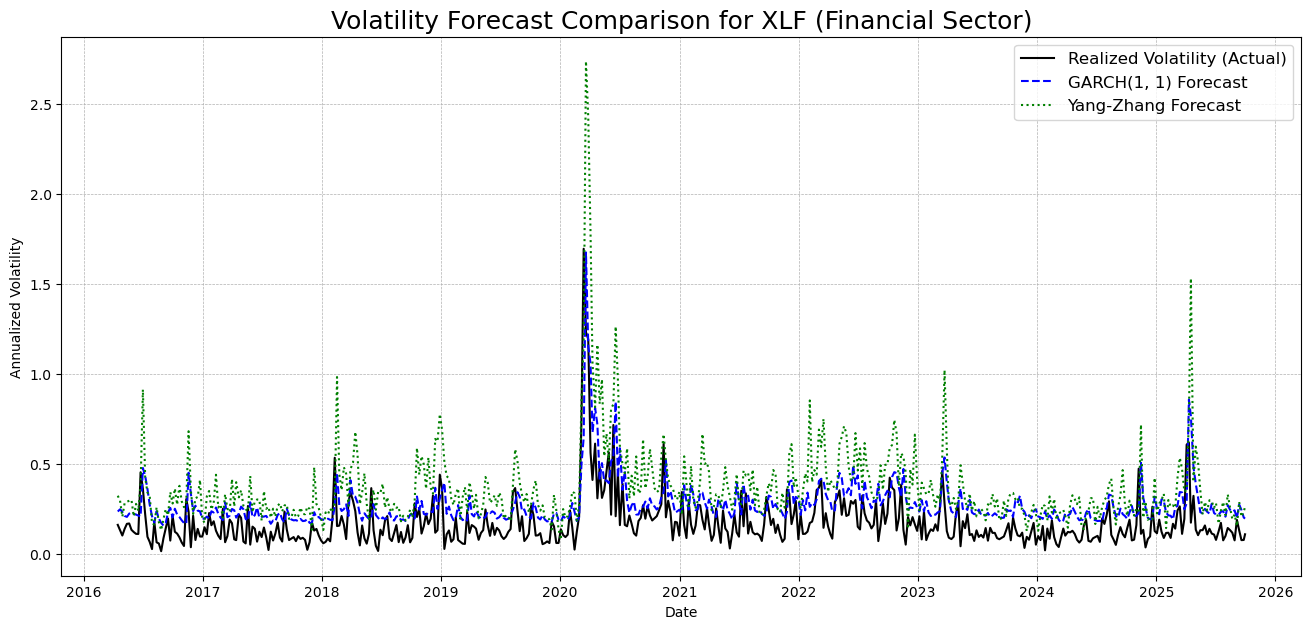

In [15]:
results_to_plot = aligned_results_data['XLF']
x = pd.to_datetime(results_to_plot['trade_date'])

plt.figure(figsize=(16, 7))
plt.plot(x, results_to_plot['realized_vol'], label='Realized Volatility (Actual)', color='black')
plt.plot(x, results_to_plot['garch'], label='GARCH(1, 1) Forecast', color='blue', linestyle='--')
plt.plot(x, results_to_plot['yang_zhang'], label='Yang-Zhang Forecast', color='green', linestyle=':')

plt.title(f'Volatility Forecast Comparison for XLF (Financial Sector)', fontsize=18)
plt.ylabel('Annualized Volatility')
plt.xlabel('Date')
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

The time-series plot for XLF (Financial Sector ETF) displays its Yang-Zhang (in green) and GARCH(1, 1) volatility forecasts (in blue), as well as the realized volatility (in black). Both forecasts tend to overestimate actual realized volatility, indicating positive bias. 

Additionally, the Yang-Zhang forecast is highly sensitive to intraday price swings, allowing it to capture the directionality of volatility well, but also making it very sensitive. The GARCH(1, 1) model, on the other hand, is much smoother and less reactive. When big volatility spikes occur (such as COVID-19), both estimators predict a spike, but the Yang-Zhang forecast is far less accurate in its magnitude (as seen through it having the highest RMSE).

We now visualize these errors by plotting the raw error (not RMSE) distribution of the GARCH(1, 1), Yang-Zhang, and Close-to-Close (as a benchmark) estimators on volatility forecasts for XLF. However, note that the estimators' behaviors are consistent across all ETFs.

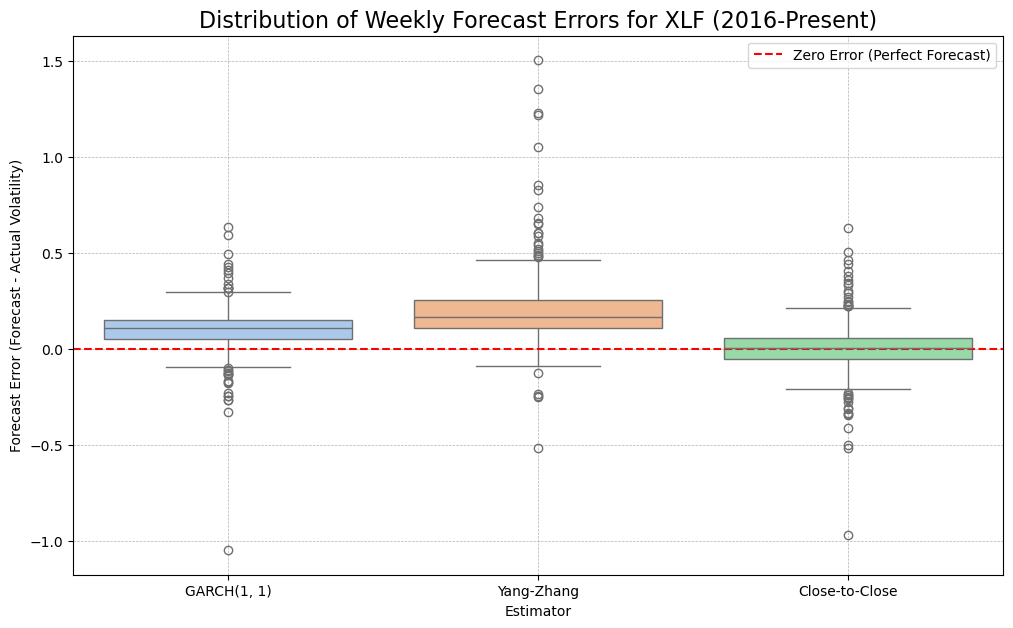

In [16]:
ticker_to_analyze = 'XLF'
results_df = aligned_results_data[ticker_to_analyze]

# Calculating raw errors
error_df = pd.DataFrame({
    'GARCH(1, 1)': results_df['garch'] - results_df['realized_vol'],
    'Yang-Zhang': results_df['yang_zhang'] - results_df['realized_vol'],
    'Close-to-Close': results_df['close_to_close'] - results_df['realized_vol'],
})

plt.figure(figsize=(12, 7))
sns.boxplot(data=error_df, palette='pastel')
plt.title(f'Distribution of Weekly Forecast Errors for {ticker_to_analyze} (2016-Present)', fontsize=16)
plt.ylabel('Forecast Error (Forecast - Actual Volatility)')
plt.xlabel('Estimator')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error (Perfect Forecast)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

We can see that the *median* forecast error for the Close-to-Close estimator is actually very close to 0, indicating less biased forecasts (as confirmed through its RMSE). The Yang-Zhang estimator, on the other hand, has a higher median forecast error and a wider range of outcomes, which was also observed in the forecast time-series plot. The GARCH model's median error is slightly higher than 0, but its range of outcomes is small as well.

However, we must also consider the estimators' correlation with realized volatility. To visualize if this truly provides a benefit, we plot regression lines for forecasted vs. realized volatilities for the GARCH(1, 1), Yang-Zhang, and Close-to-Close estimators on XLF (other ETFs show this same pattern).

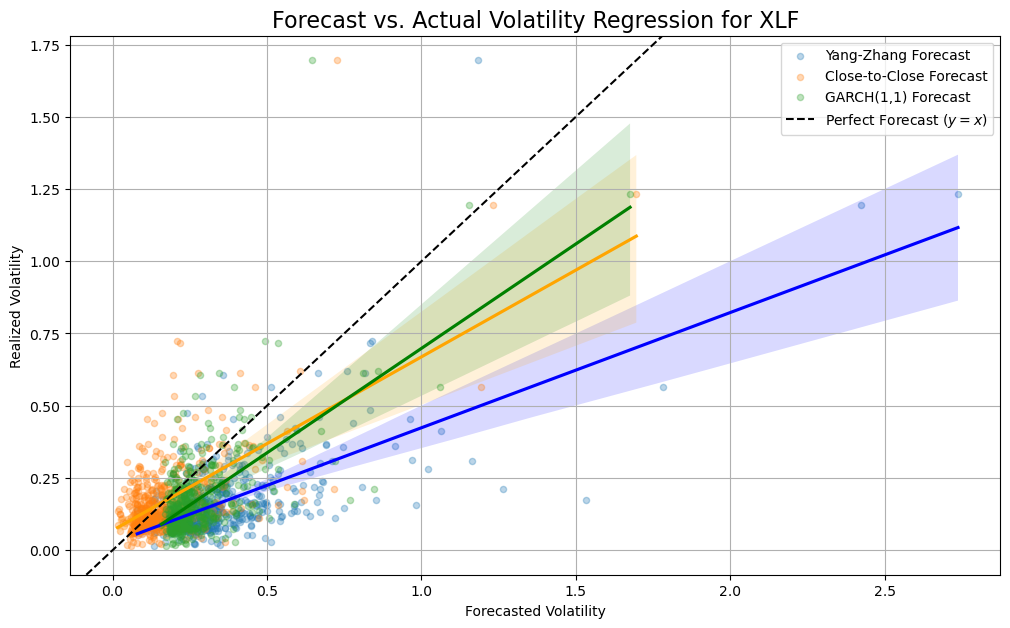

In [17]:
ticker_to_analyze = 'XLF'
results_df = aligned_results_data[ticker_to_analyze]

# Scatter plots with reg lines
plt.figure(figsize=(12, 7))
sns.regplot(x='yang_zhang', y='realized_vol', data=results_df, scatter_kws={'s': 20, 'alpha': 0.3}, line_kws={'color': 'blue'}, label='Yang-Zhang Forecast')
sns.regplot(x='close_to_close', y='realized_vol', data=results_df, scatter_kws={'s': 20, 'alpha': 0.3}, line_kws={'color': 'orange'}, label='Close-to-Close Forecast')
sns.regplot(x='garch', y='realized_vol', data=results_df, scatter_kws={'s': 20, 'alpha': 0.3}, line_kws={'color': 'green'}, label='GARCH(1,1) Forecast')

# Perfect forecast 45-degree line
plt.axline((0,0), slope=1, color='black', linestyle='--', label='Perfect Forecast ($y=x$)')
plt.title('Forecast vs. Actual Volatility Regression for XLF', fontsize=16)
plt.xlabel('Forecasted Volatility')
plt.ylabel('Realized Volatility')
plt.grid(True)
plt.legend()
plt.show()

The plot highlights a key trade-off present in forecasting: the bias-variance trade-off. The Yang-Zhang estimator produced the highest $R^2$, meaning its forecasts were more tightly clustered around their own best-fit linear regression line. In a sense, the linear relationship between the Yang-Zhang forecast and the actual outcome is stronger and more consistent, but not necessarily accurate. On the other hand, the Close-to-Close estimator's regression line is much closer to the perfectly correlated forecast, but the observations are more scattered and spread out, leading to a lower $R^2$.

However, the GARCH(1, 1) model strikes a powerful balance between the two, almost matching the slope of the Close-to-Close estimator. Additionally, the points are very tightly clustered around its regression line, which can also be quantified through its $R^2$ being one of the highest out of the estimators.

Essentially, the Yang-Zhang estimator has lower variance but higher bias, while the Close-to-Close is the opposite, as it produces less reliable but more accurate forecasts on average. Ultimately, the GARCH(1, 1) model provides a very good balancing point on this trade-off.

## Conclusion

Given all of the results from our backtest, my recommendation for a forecasting methodology to be used in making investment decisions is the **GARCH(1, 1) model**. THe decision was not immediately obvious from the summary table along, as the model with the best $R^2$ (Yang-Zhang) has the worst RMSE, and the model with the best RMSE (Close-to-Close) has the worst $R^2$. However, a deeper look at this trade-off reveals why GARCH is a better choice.

From this analysis, there are three key advantages of using a GARCH(1, 1):

1. GARCH(1, 1) offers the best balance between $R^2$ and RMSE, performing well on both metrics (high $R^2$ and second-best RMSE).
2. GARCH is a reliable and accurate forecaster, as seen in the forecast regression plot. Both the GARCH(1, 1) and the Close-to-Close estimator were near $y=x$ (perfect forecast), but the observations for the GARCH model were more tightly clustered around its line of best-fit, indicating more reliability.
3. GARCH is adaptive. The model is trained on at least 7 years of data (in our case) for each forecast, allowing it to incorporate the memory of past volatility shocks. Additionally, an expanding window can be used to incorporate more data, and many parameters can be adjusted for better goodness-of-fit.

In conclusion, while other estimators may excel on a single metric, the GARCH(1, 1) model is the only one that delivers a combination of directional accuracy, reasonable error magnitude, and adaptability.